# Training Log Visualization

Load a training log folder and visualize the results.

## Instructions
1. Set `LOG_FOLDER` below to a training run folder (e.g. `"../logs/2026-07-14_12-30-00"`)
2. Run all cells

In [1]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
LOG_FOLDER = "../logs/2026-07-25_20-41-19"  # <-- edit this path

log_dir = Path(LOG_FOLDER)
if not log_dir.exists():
    raise FileNotFoundError(f"Log folder not found: {log_dir.resolve()}")

print(f"Loading training logs from: {log_dir.resolve()}")

Loading training logs from: E:\Kuliah\Skripsi\Project\SUMO-dinamic-tuning-AI\logs\2026-07-25_20-41-19


In [3]:
# ── Config ──
cfg_path = log_dir / "config.json"
if cfg_path.exists():
    with open(cfg_path) as f:
        config = json.load(f)
    print("Training Configuration:")
    for k, v in config.items():
        print(f"  {k}: {v}")
else:
    config = {}
    print("No config.json found.")

print()

# ── Summary ──
summary_path = log_dir / "summary.json"
if summary_path.exists():
    with open(summary_path) as f:
        summary = json.load(f)
    df_summary = pd.DataFrame(summary)
    print("Per-Iteration Summary:")
    display(df_summary)
else:
    df_summary = None
    print("No summary.json found.")

print()

# ── Metrics ──
metrics_path = log_dir / "metrics.csv"
if not metrics_path.exists():
    raise FileNotFoundError(f"metrics.csv not found in {log_dir}")

df = pd.read_csv(metrics_path)

KNOWN_COLS = {
    "iteration", "data_point", "step_in_data",
    "reward", "sim_south", "sim_north",
    "expected_south", "expected_north",
    "error_south", "error_north",
    "epsilon", "loss", "error_delta",
}
param_cols = [c for c in df.columns if c not in KNOWN_COLS]
print(f"Detected parameter column(s): {param_cols}")
print(f"Total rows: {len(df)}")
print(f"Iterations:  {df['iteration'].nunique()}")
print(f"Data points: {df['data_point'].nunique() if 'data_point' in df.columns else 'N/A'}")
print(f"Columns: {list(df.columns)}")
print()
print("First 5 rows:")
display(df.head())

for col in ["reward", "epsilon", "loss"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
for col in param_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print()

# ── Actions ──
actions_path = log_dir / "actions.csv"
if actions_path.exists():
    df_actions = pd.read_csv(actions_path)
    print(f"Actions log — {len(df_actions)} rows")
    display(df_actions.head())
else:
    df_actions = None
    print("No actions.csv found.")

Training Configuration:
  iterations: 40
  sumo_binary: sumo
  warmup_minutes: 5
  period_minutes: 10
  reward_scale: 1.0
  flow: reset
  steps_per_data: 10
  lr: 0.001
  gamma: 0.99
  batch_size: 32
  buffer_capacity: 10000
  replay_per_step: 5
  epsilon_start: 1.0
  epsilon_min: 0.1
  epsilon_decay: 0.93

Per-Iteration Summary:


,iteration,total_reward,avg_reward,avg_loss,epsilon,total_steps
0,1,2.582,0.009,0.007846,0.9300,280
1,2,0.723,0.003,0.003973,0.8649,280
2,3,3.095,0.011,0.003330,0.8044,280
3,4,3.971,0.014,0.002383,0.7481,280
4,5,3.346,0.012,0.002163,0.6957,280
5,6,3.683,0.013,0.002070,0.6470,280
6,7,3.498,0.012,0.001838,0.6017,280
7,8,3.643,0.013,0.001666,0.5596,280
8,9,5.152,0.018,0.001698,0.5204,280
9,10,4.204,0.015,0.001649,0.4840,280



Detected parameter column(s): ['speedFactor', 'improvement']
Total rows: 11200
Iterations:  40
Data points: 28
Columns: ['iteration', 'data_point', 'step_in_data', 'reward', 'sim_south', 'sim_north', 'expected_south', 'expected_north', 'error_south', 'error_north', 'speedFactor', 'epsilon', 'loss', 'improvement']

First 5 rows:


,iteration,data_point,step_in_data,reward,sim_south,sim_north,expected_south,expected_north,error_south,error_north,speedFactor,epsilon,loss,improvement
0,1,0,1,-0.042,94,68,98,71,-4.0,-3.0,0.99,1.0,NaN,-0.005102
1,1,0,2,-0.057,91,68,98,71,-7.0,-3.0,0.98,1.0,NaN,-0.020408
2,1,0,3,-0.029,95,69,98,71,-3.0,-2.0,1.08,1.0,NaN,0.007042
3,1,0,4,-0.029,95,69,98,71,-3.0,-2.0,1.08,1.0,NaN,0.007042
4,1,0,5,-0.029,95,69,98,71,-3.0,-2.0,1.08,1.0,NaN,0.007042



Actions log — 11200 rows


,iteration,data_point,step_in_data,action_index,delta_speedFactor
0,1,0,1,4,-0.01
1,1,0,2,4,-0.01
2,1,0,3,3,0.10
3,1,0,4,2,0.00
4,1,0,5,2,0.00


In [4]:
# ── Available model checkpoints ──────────────────────────────
ckpt_files = sorted([
    f.name for f in log_dir.iterdir()
    if f.suffix == ".pt"
])
if ckpt_files:
    print("Checkpoints in this log folder:")
    for f in ckpt_files:
        fsize = (log_dir / f).stat().st_size
        print(f"  {f}  ({fsize / 1024:.1f} KB)")
    has_best = any("best" in f for f in ckpt_files)
    has_latest = any("latest" in f for f in ckpt_files)
    print()
    if has_best:
        print(">> Use dqn_best.pt for evaluation (best avg_reward across iterations)")
    if has_latest:
        print(">> Use dqn_latest.pt for the final iteration checkpoint")
else:
    print("No .pt checkpoint files found in this log folder.")

Checkpoints in this log folder:
  dqn_best.pt  (85.4 KB)
  dqn_iter_1.pt  (85.5 KB)
  dqn_iter_10.pt  (85.5 KB)
  dqn_iter_11.pt  (85.5 KB)
  dqn_iter_12.pt  (85.5 KB)
  dqn_iter_13.pt  (85.5 KB)
  dqn_iter_14.pt  (85.5 KB)
  dqn_iter_15.pt  (85.5 KB)
  dqn_iter_16.pt  (85.5 KB)
  dqn_iter_17.pt  (85.5 KB)
  dqn_iter_18.pt  (85.5 KB)
  dqn_iter_19.pt  (85.5 KB)
  dqn_iter_2.pt  (85.5 KB)
  dqn_iter_20.pt  (85.5 KB)
  dqn_iter_21.pt  (85.5 KB)
  dqn_iter_22.pt  (85.5 KB)
  dqn_iter_23.pt  (85.5 KB)
  dqn_iter_24.pt  (85.5 KB)
  dqn_iter_25.pt  (85.5 KB)
  dqn_iter_26.pt  (85.5 KB)
  dqn_iter_27.pt  (85.5 KB)
  dqn_iter_28.pt  (85.5 KB)
  dqn_iter_29.pt  (85.5 KB)
  dqn_iter_3.pt  (85.5 KB)
  dqn_iter_30.pt  (85.5 KB)
  dqn_iter_31.pt  (85.5 KB)
  dqn_iter_32.pt  (85.5 KB)
  dqn_iter_33.pt  (85.5 KB)
  dqn_iter_34.pt  (85.5 KB)
  dqn_iter_35.pt  (85.5 KB)
  dqn_iter_36.pt  (85.5 KB)
  dqn_iter_37.pt  (85.5 KB)
  dqn_iter_38.pt  (85.5 KB)
  dqn_iter_39.pt  (85.5 KB)
  dqn_iter_4.pt  (85.5

In [5]:
# Chart 1 data — Reward over all steps

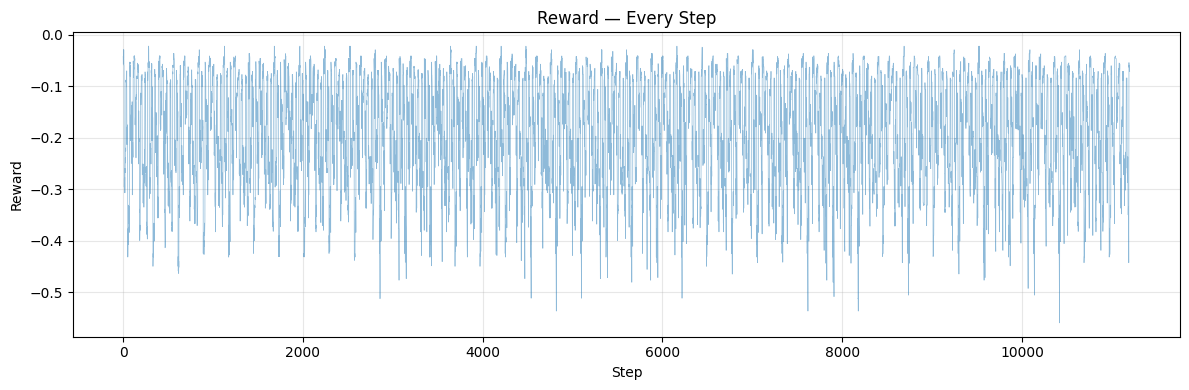

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["reward"], alpha=0.5, linewidth=0.5)
ax.set_xlabel("Step"); ax.set_ylabel("Reward")
ax.set_title("Reward — Every Step")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Chart 2 data — Loss over all steps
loss_clean = df["loss"].dropna()
print(f"Loss rows with data: {len(loss_clean)} / {len(df)}")

Loss rows with data: 11169 / 11200


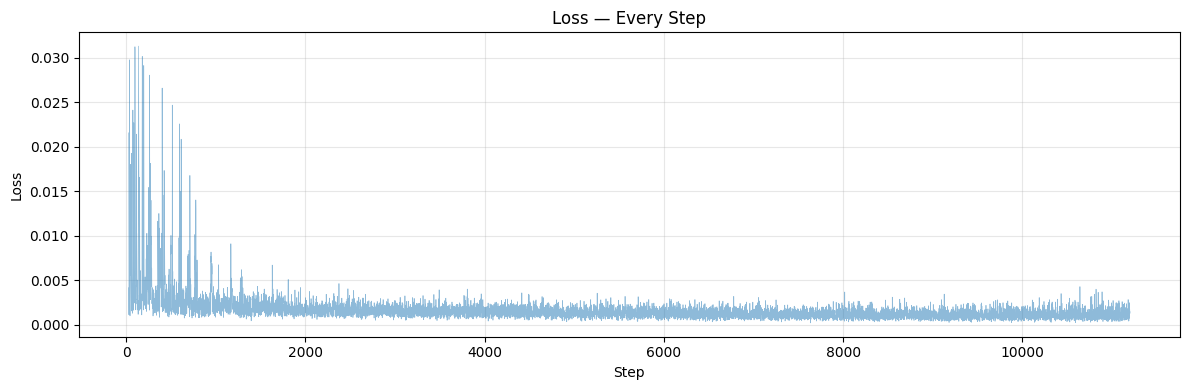

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
if len(loss_clean):
    ax.plot(loss_clean.index, loss_clean.values, alpha=0.5, linewidth=0.5)
    ax.set_xlabel("Step"); ax.set_ylabel("Loss")
    ax.set_title("Loss — Every Step")
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, "No loss data", ha="center", va="center", transform=ax.transAxes)
plt.tight_layout()
plt.show()

In [9]:
# Chart 3 data — Average reward per iteration
if df_summary is not None and "avg_reward" in df_summary.columns:
    iter_ids = df_summary["iteration"]
    avg_rew = df_summary["avg_reward"]
    src = "summary.json"
else:
    iter_ids = df.groupby("iteration")["reward"].mean().index
    avg_rew = df.groupby("iteration")["reward"].mean().values
    src = "raw metrics"
print(f"Source: {src}, iterations: {len(iter_ids)}")

Source: summary.json, iterations: 40


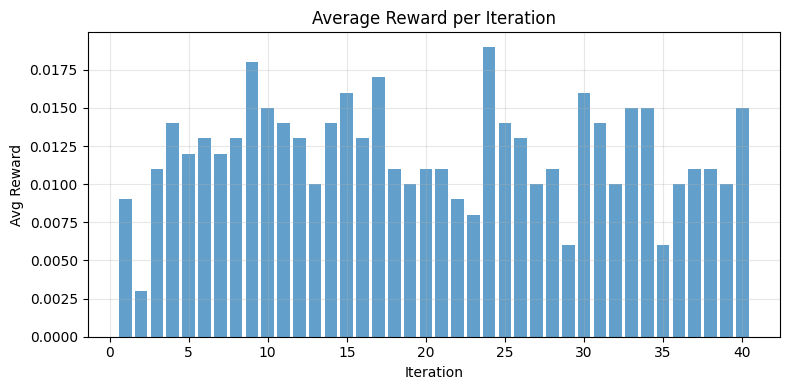

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(iter_ids, avg_rew, alpha=0.7)
ax.set_xlabel("Iteration"); ax.set_ylabel("Avg Reward")
ax.set_title("Average Reward per Iteration")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Chart 4 data — Average loss per iteration
if df_summary is not None and "avg_loss" in df_summary.columns:
    _loss_vals = df_summary["avg_loss"].dropna()
    if len(_loss_vals):
        iter_loss_ids = df_summary.loc[_loss_vals.index, "iteration"]
        avg_loss_vals = _loss_vals.values
        src = "summary.json"
    else:
        iter_loss_ids = None
        src = "none"
else:
    grp = df.groupby("iteration")["loss"].mean().dropna()
    if len(grp):
        iter_loss_ids = grp.index
        avg_loss_vals = grp.values
        src = "raw metrics"
    else:
        iter_loss_ids = None
        src = "none"
print(f"Source: {src}, iterations with loss: {len(avg_loss_vals) if iter_loss_ids is not None else 0}")

Source: summary.json, iterations with loss: 40


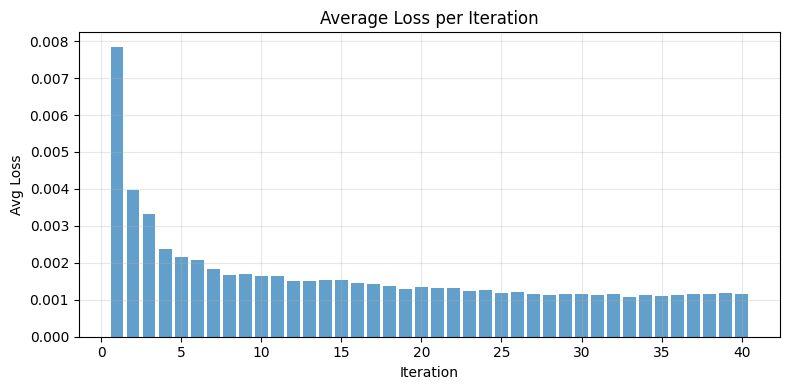

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
if iter_loss_ids is not None and len(iter_loss_ids):
    ax.bar(iter_loss_ids, avg_loss_vals, alpha=0.7)
    ax.set_xlabel("Iteration"); ax.set_ylabel("Avg Loss")
    ax.set_title("Average Loss per Iteration")
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, "No loss data", ha="center", va="center", transform=ax.transAxes)
plt.tight_layout()
plt.show()

In [13]:
# Chart 5 data — Epsilon decay
if df_summary is not None and "epsilon" in df_summary.columns:
    eps_iters = df_summary["iteration"]
    eps_vals = df_summary["epsilon"]
    src = "summary.json"
else:
    grp = df.groupby("iteration")["epsilon"].first()
    eps_iters = grp.index
    eps_vals = grp.values
    src = "raw metrics"
print(f"Source: {src}, iterations: {len(eps_iters)}")

Source: summary.json, iterations: 40


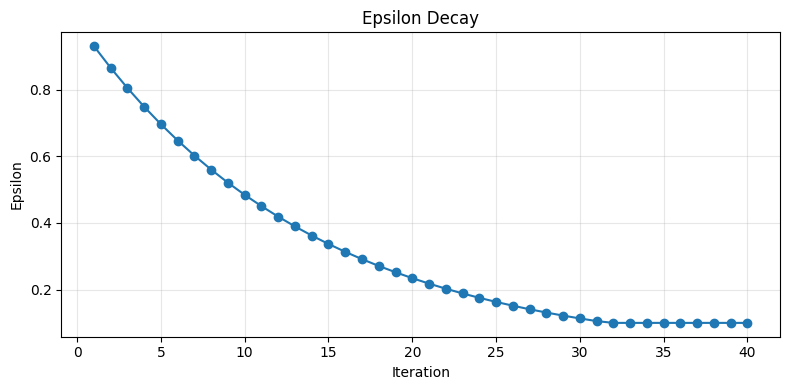

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(eps_iters, eps_vals, "o-")
ax.set_xlabel("Iteration"); ax.set_ylabel("Epsilon")
ax.set_title("Epsilon Decay")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Chart 6 data — Parameter values over all steps
print(f"Parameter columns: {param_cols}")

Parameter columns: ['speedFactor', 'improvement']


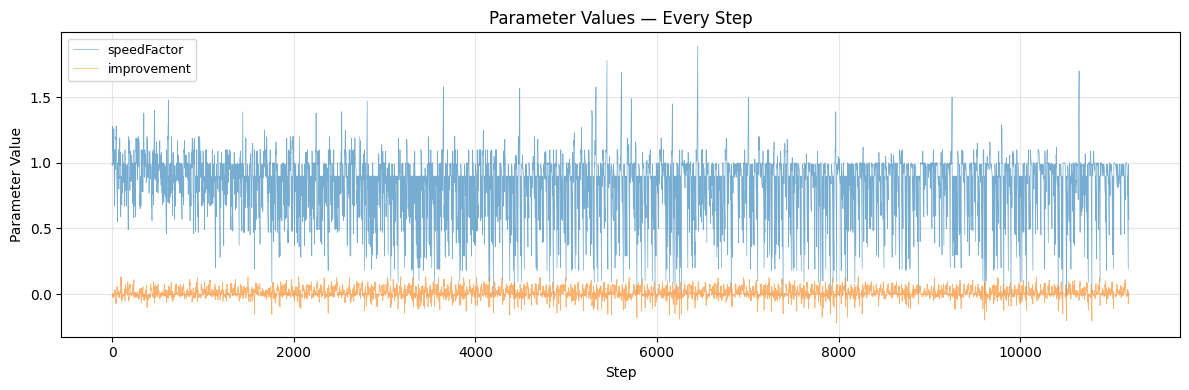

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))
if param_cols:
    for col in param_cols:
        ax.plot(df.index, df[col], alpha=0.6, linewidth=0.5, label=col)
    ax.set_xlabel("Step"); ax.set_ylabel("Parameter Value")
    ax.set_title("Parameter Values — Every Step")
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "No parameter columns", ha="center", va="center", transform=ax.transAxes)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# Chart 7 data — Total and avg reward per data point across iterations
SELECTED_INDICES = [3, 4, 7, 5, 6]  # <-- edit

subset = df[df["data_point"].isin(SELECTED_INDICES)].copy()
available = sorted(df["data_point"].unique())
print(f"Selected: {SELECTED_INDICES}")
print(f"Available data points: {available}")

if not subset.empty:
    grp = subset.groupby(["iteration", "data_point"])["reward"].agg(["sum", "mean"]).reset_index()
    print(f"Grouped into {len(grp)} (iteration, data_point) rows")
    display(grp)
else:
    grp = None
    print("WARNING: No data found for selected indices.")

Selected: [3, 4, 7, 5, 6]
Available data points: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27)]
Grouped into 200 (iteration, data_point) rows


,iteration,data_point,sum,mean
0,1,3,-0.852,-0.0852
1,1,4,-1.934,-0.1934
2,1,5,-3.992,-0.3992
3,1,6,-3.503,-0.3503
4,1,7,-0.647,-0.0647
...,...,...,...,...
195,40,3,-0.845,-0.0845
196,40,4,-1.572,-0.1572
197,40,5,-4.122,-0.4122
198,40,6,-3.464,-0.3464


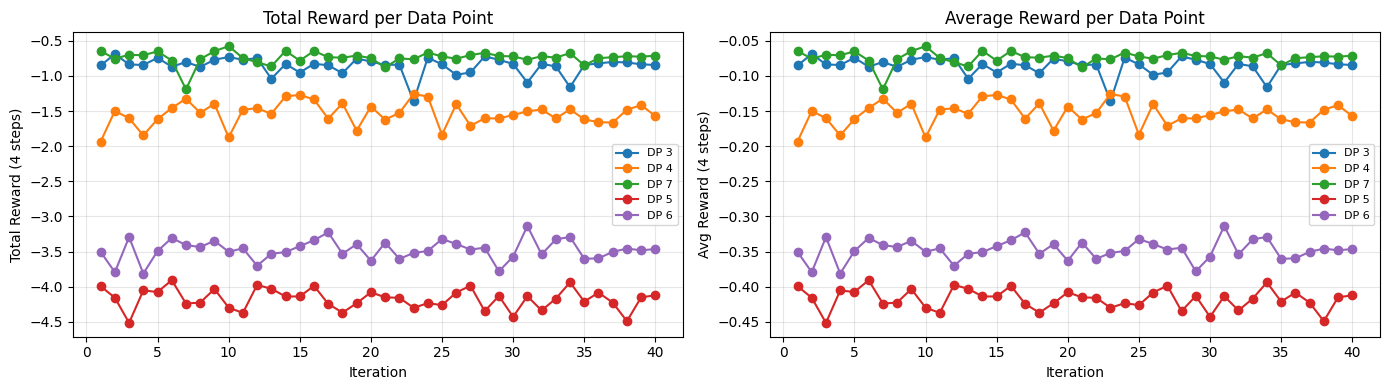

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

if grp is not None and not grp.empty:
    for dp_id in SELECTED_INDICES:
        dp_grp = grp[grp["data_point"] == dp_id].sort_values("iteration")
        if dp_grp.empty:
            continue
        ax1.plot(dp_grp["iteration"], dp_grp["sum"], "o-", label=f"DP {dp_id}")
        ax2.plot(dp_grp["iteration"], dp_grp["mean"], "o-", label=f"DP {dp_id}")
    ax1.set_xlabel("Iteration"); ax1.set_ylabel("Total Reward (4 steps)")
    ax1.set_title("Total Reward per Data Point"); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)
    ax2.set_xlabel("Iteration"); ax2.set_ylabel("Avg Reward (4 steps)")
    ax2.set_title("Average Reward per Data Point"); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
else:
    ax1.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax1.transAxes)
    ax2.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax2.transAxes)
plt.tight_layout()
plt.show()

In [19]:
# Chart 8 data — Sim vs Expected (same SELECTED_INDICES as above)
SELECTED_INDICES_V2 = [0, 1, 2, 5, 6]  # <-- edit

subset_v2 = df[df["data_point"].isin(SELECTED_INDICES_V2)].copy()
print(f"Selected: {SELECTED_INDICES_V2}")
print(f"Rows: {len(subset_v2)}")

Selected: [0, 1, 2, 5, 6]
Rows: 2000


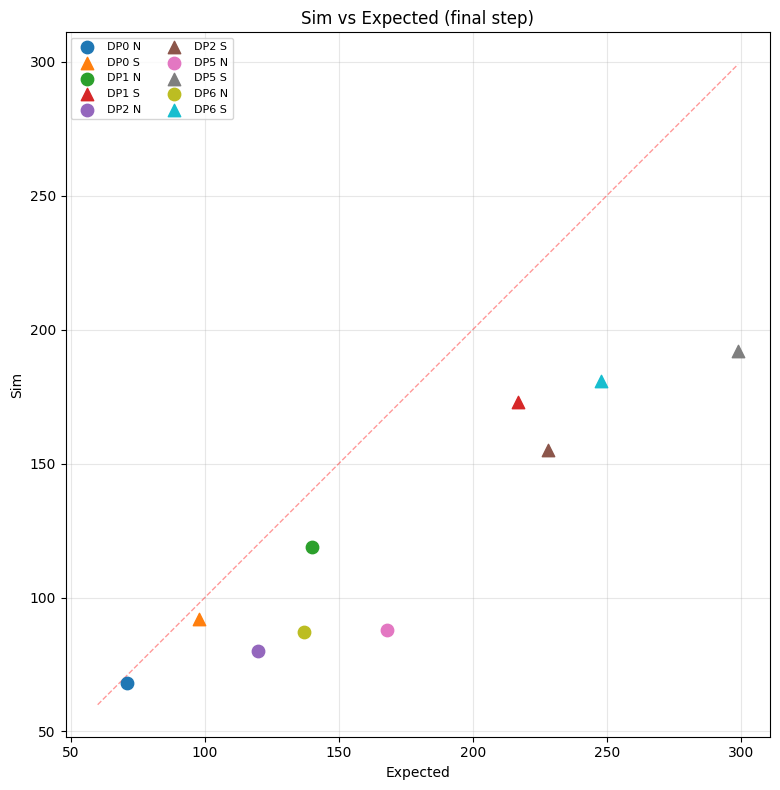

In [20]:
fig, ax = plt.subplots(figsize=(8, 8))
if not subset_v2.empty:
    for dp_id in SELECTED_INDICES_V2:
        dp_data = subset_v2[subset_v2["data_point"] == dp_id]
        if dp_data.empty:
            continue
        last_step = dp_data["step_in_data"].max()
        last = dp_data[dp_data["step_in_data"] == last_step]
        if last.empty:
            last = dp_data
        row = last.iloc[-1]
        ax.scatter(row["expected_north"], row["sim_north"],
                   marker="o", s=80, label=f"DP{dp_id} N", zorder=5)
        ax.scatter(row["expected_south"], row["sim_south"],
                   marker="^", s=80, label=f"DP{dp_id} S", zorder=5)

    all_exp = pd.concat([subset_v2["expected_north"], subset_v2["expected_south"]])
    all_sim = pd.concat([subset_v2["sim_north"], subset_v2["sim_south"]])
    if len(all_exp) > 0:
        lo = min(all_exp.min(), all_sim.min())
        hi = max(all_exp.max(), all_sim.max())
        ax.plot([lo, hi], [lo, hi], "r--", alpha=0.4, linewidth=1)
    ax.set_xlabel("Expected"); ax.set_ylabel("Sim")
    ax.set_title("Sim vs Expected (final step)")
    ax.legend(fontsize=8, ncol=2)
    ax.set_aspect("equal")
else:
    ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# Chart 9 data — Parameter tuning by data point
SELECTED_INDICES_V3 = [0, 1, 2, 5]  # <-- edit

subset_v3 = df[df["data_point"].isin(SELECTED_INDICES_V3)].copy()
print(f"Selected: {SELECTED_INDICES_V3}")
print(f"Rows: {len(subset_v3)}")
print(f"Parameter columns: {param_cols}")

Selected: [0, 1, 2, 5]
Rows: 1600
Parameter columns: ['speedFactor', 'improvement']


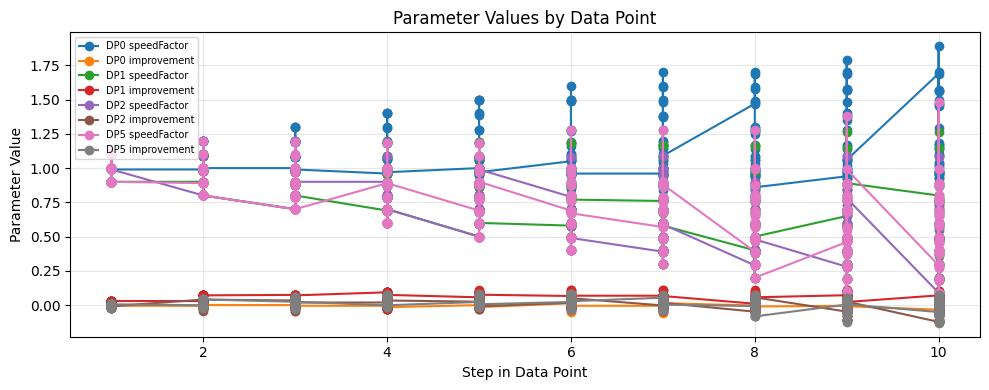

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
if not subset_v3.empty and param_cols:
    for dp_id in SELECTED_INDICES_V3:
        dp_data = subset_v3[subset_v3["data_point"] == dp_id].sort_values("step_in_data")
        if dp_data.empty:
            continue
        for pc in param_cols:
            ax.plot(dp_data["step_in_data"], dp_data[pc],
                    "o-", label=f"DP{dp_id} {pc}")
    ax.set_xlabel("Step in Data Point"); ax.set_ylabel("Parameter Value")
    ax.set_title("Parameter Values by Data Point")
    ax.legend(fontsize=7)
elif not param_cols:
    ax.text(0.5, 0.5, "No parameter columns", ha="center", va="center", transform=ax.transAxes)
else:
    ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
if not subset_v3.empty:
    last_steps = subset_v3[subset_v3["step_in_data"] == subset_v3["step_in_data"].max()]
    print("Final-step values for selected data points:")
    display(last_steps.reset_index(drop=True))
else:
    print("No data to display.")

Final-step values for selected data points:


,iteration,data_point,step_in_data,reward,sim_south,sim_north,expected_south,expected_north,error_south,error_north,speedFactor,epsilon,loss,improvement
0,1,0,10,-0.060,89,69,98,71,-9.0,-2.0,1.17,1.00,NaN,-0.023570
1,1,1,10,-0.307,163,89,217,140,-54.0,-51.0,1.26,1.00,NaN,-0.029608
2,1,2,10,-0.220,179,93,228,120,-49.0,-27.0,0.77,1.00,NaN,0.031360
3,1,5,10,-0.374,200,98,299,168,-99.0,-70.0,0.65,1.00,0.001669,0.056717
4,2,0,10,-0.052,92,68,98,71,-6.0,-3.0,0.97,0.93,0.002375,-0.015306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,39,5,10,-0.385,197,96,299,168,-102.0,-72.0,0.76,0.10,0.001777,0.045748
156,40,0,10,-0.052,92,68,98,71,-6.0,-3.0,0.93,0.10,0.000971,-0.015306
157,40,1,10,-0.176,173,119,217,140,-44.0,-21.0,0.55,0.10,0.001525,0.100576
158,40,2,10,-0.327,155,80,228,120,-73.0,-40.0,0.18,0.10,0.001806,-0.075439


In [32]:
# Chart 10 data — Error Delta across all training steps
ed_clean = df["error_delta"].dropna() if "error_delta" in df.columns else pd.Series(dtype=float)
if len(ed_clean):
    print(f"Error delta rows with data: {len(ed_clean)} / {len(df)}")
    print(f"Mean error_delta: {ed_clean.mean():+.6f}")
    print(f"Std error_delta:  {ed_clean.std():.6f}")
else:
    print("No error_delta column found in metrics.csv")

No error_delta column found in metrics.csv


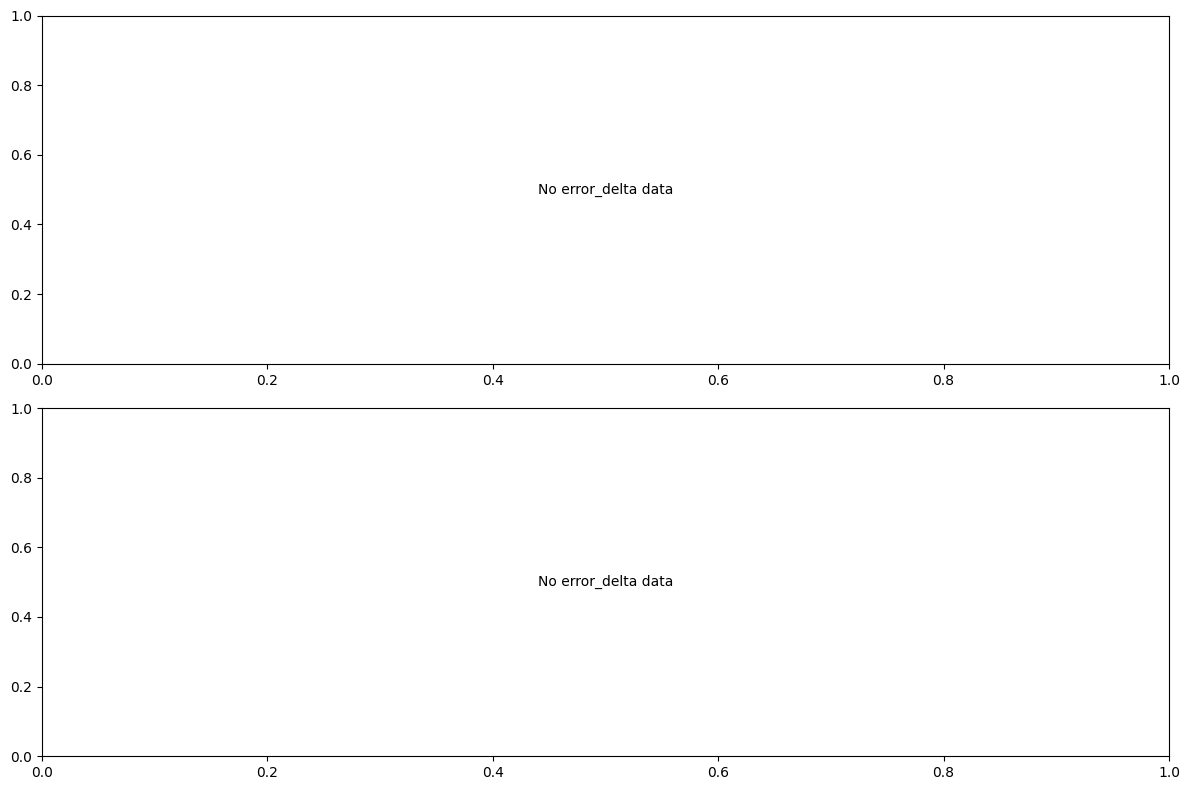

In [33]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

if "error_delta" in df.columns and len(ed_clean):
    # Top: raw error_delta per step
    ax1.plot(df.index, df["error_delta"], alpha=0.4, linewidth=0.5, color="steelblue")
    ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax1.set_xlabel("Step")
    ax1.set_ylabel("Error Delta")
    ax1.set_title("Error Delta per Step (DQN MAPE – Baseline MAPE): negative = improvement")
    ax1.grid(True, alpha=0.3)

    # Bottom: rolling mean error_delta per iteration
    iter_mean = df.groupby("iteration")["error_delta"].mean()
    colors = ["#2ecc71" if v < 0 else "#e74c3c" for v in iter_mean.values]
    ax2.bar(iter_mean.index, iter_mean.values, color=colors, edgecolor="black", alpha=0.8)
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("Mean Error Delta")
    ax2.set_title("Mean Error Delta per Iteration (green = DQN beat baseline)")
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(range(int(min(iter_mean.index)), int(max(iter_mean.index)) + 1))
else:
    ax1.text(0.5, 0.5, "No error_delta data", ha="center", va="center", transform=ax1.transAxes)
    ax2.text(0.5, 0.5, "No error_delta data", ha="center", va="center", transform=ax2.transAxes)

plt.tight_layout()
plt.show()

In [34]:
# Chart 11 data — Error Delta for a specific data point
TARGET_DATA_POINT = 19  # <-- change this to the data point index you want to inspect

# Load baseline.csv if available
baseline_csv = log_dir / "baseline.csv"
baseline_dict = None
if baseline_csv.exists():
    df_bl = pd.read_csv(baseline_csv)
    baseline_dict = dict(zip(df_bl["data_point"], df_bl["mape"]))
    print(f"Loaded baseline.csv: {len(baseline_dict)} data points")
else:
    print("No baseline.csv found — DQN-only chart")

if "error_delta" in df.columns:
    dp_df = df[df["data_point"] == TARGET_DATA_POINT].copy()
    if not dp_df.empty:
        dp_ed = dp_df.groupby("iteration")["error_delta"].mean().reset_index()
        dp_ed.columns = ["iteration", "mean_error_delta"]
        print(f"Data point {TARGET_DATA_POINT + 1}: {len(dp_ed)} iterations")
        display(dp_ed)
    else:
        dp_ed = None
        print(f"No data for data_point={TARGET_DATA_POINT}")
else:
    dp_ed = None
    dp_df = None
    print("No error_delta column found")

Loaded baseline.csv: 28 data points
No error_delta column found


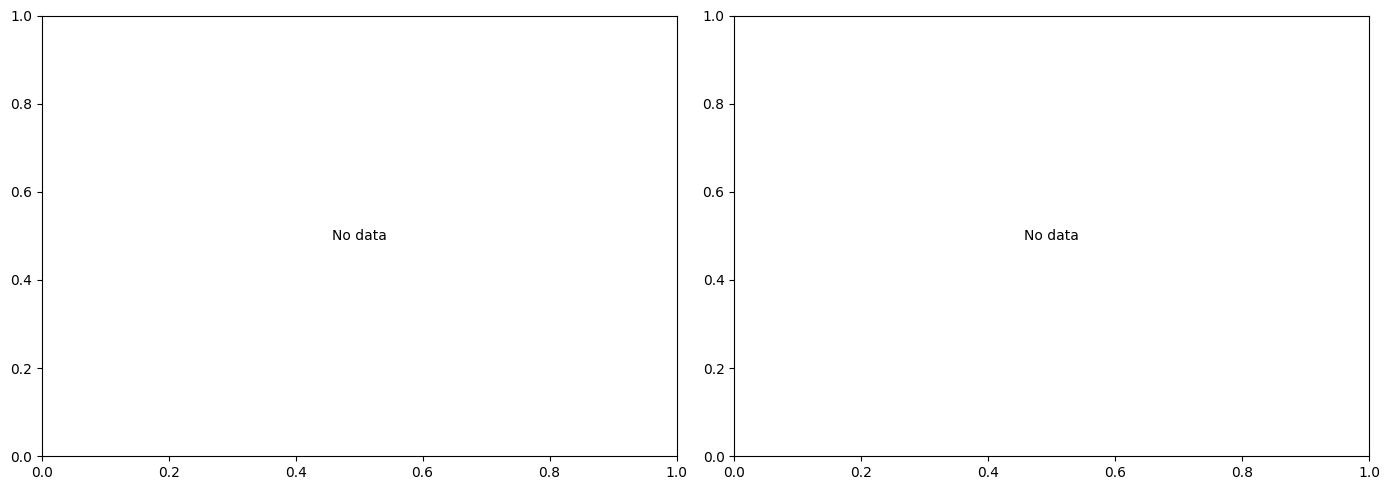

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

if dp_ed is not None and not dp_ed.empty:
    # Left: error_delta over iterations
    colors = ["#2ecc71" if v < 0 else "#e74c3c" for v in dp_ed["mean_error_delta"]]
    ax1.bar(dp_ed["iteration"], dp_ed["mean_error_delta"], color=colors, edgecolor="black", alpha=0.8)
    ax1.axhline(0, color="black", linewidth=0.8)
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Mean Error Delta")
    ax1.set_title(f"Error Delta per Iteration (data point {TARGET_DATA_POINT})")
    ax1.grid(True, alpha=0.3)
    
    # Fix for left chart: set x-ticks to show every 1 point
    ax1.set_xticks(range(int(min(dp_ed["iteration"])), int(max(dp_ed["iteration"])) + 1))

    # Right: MAPE vs baseline over iterations
    dp_mape = dp_df.groupby("iteration")["reward"].apply(lambda x: -x.mean()).reset_index()
    dp_mape.columns = ["iteration", "dqn_mape"]
    if baseline_dict is not None and TARGET_DATA_POINT in baseline_dict:
        bl_mape = baseline_dict[TARGET_DATA_POINT]
        ax2.axhline(bl_mape, color="gray", linestyle="--", linewidth=1.5, label=f"Baseline (SUMO default): {bl_mape:.4f}")
    ax2.plot(dp_mape["iteration"], dp_mape["dqn_mape"], "o-", color="steelblue", label="DQN MAPE")
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("MAPE")
    ax2.set_title(f"MAPE over Iterations (data point {TARGET_DATA_POINT})")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Fix for right chart: set x-ticks to show every 1 point
    ax2.set_xticks(range(int(min(dp_mape["iteration"])), int(max(dp_mape["iteration"])) + 1))
    
else:
    ax1.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax1.transAxes)
    ax2.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax2.transAxes)

plt.tight_layout()
plt.show()